# Attenuator Grid Lab

Notebook playground for live throughput monitoring, background grid acquisition, selected-slice fits, and direct NumPy record inspection.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from hispec_fibpcb import HispecFibPcb, AttenuatorGridDataset
%cd ../../

In [2]:
pcb = HispecFibPcb("hispec.caltech.edu", device="hsfib-tib")
laser = "1028y"
channel = "yj"

Start non-auto throughput telemetry. This collector runs in the background; do not use the blocking `plot_live()` method while acquiring a grid.

In [6]:
# throughput = pcb.measure_throughput(laser, channel=channel, autolevel=False, collect=True, format="binary", max_samples=20000)
throughput 

AttenuatorGridDataset(
  records=11236,
  channel='yj',
  laser=('1028y',),
  dac1_mv=(0, 3300),
  dac2_mv=(0, 3300)
)

Start the grid acquisition in a background Python thread so the notebook remains usable.

In [ ]:
dac_values = np.r_[0, 300, 600, 900, np.arange(1300, 3301, 100)]
grid_job = pcb.attenuator_grid_probe_async(
    laser,
    dac1_mv=dac_values,
    dac2_mv=dac_values,
    dwell_s=1.1,
    laser_pct=50,
    channel=channel,
)
grid_job

Watch throughput while the grid job runs. Stop this cell manually when enough context is visible, or let it end when the grid job completes.

In [ ]:
while not grid_job.done:
    rec = throughput.to_recarray()
    clear_output(wait=True)
    print(f"grid done={grid_job.done}, throughput samples={len(rec)}")
    if len(rec):
        fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
        axes[0].plot(rec.t_ms, rec.pd_net_mv, marker='.', linestyle='none', markersize=2)
        axes[0].set_ylabel('pd_net_mv')
        axes[1].plot(rec.t_ms, rec.atten_db, marker='.', linestyle='none', markersize=2)
        axes[1].set_ylabel('atten_db')
        axes[1].set_xlabel('t_ms')
        display(fig)
        plt.close(fig)
    time.sleep(1.0)

x = grid_job.wait()
x

In [ ]:
x.save()

In [20]:
x = AttenuatorGridDataset.load('/Users/jibailey/src/hispec-zephyr-mlang/attenuator_grid_dataset_bkup.npz')
x

AttenuatorGridDataset(
  records=625,
  channel='yj',
  laser=('1028y',),
  dac1_mv=(0, 3300),
  dac2_mv=(0, 3300)
)

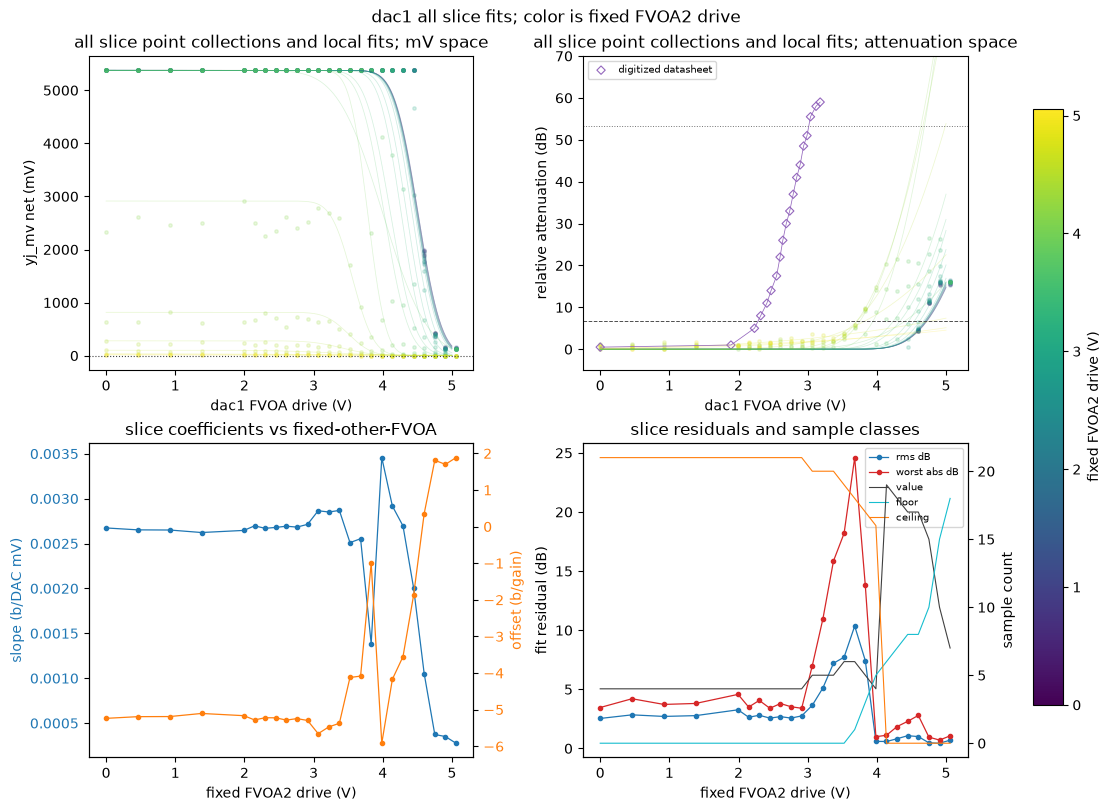

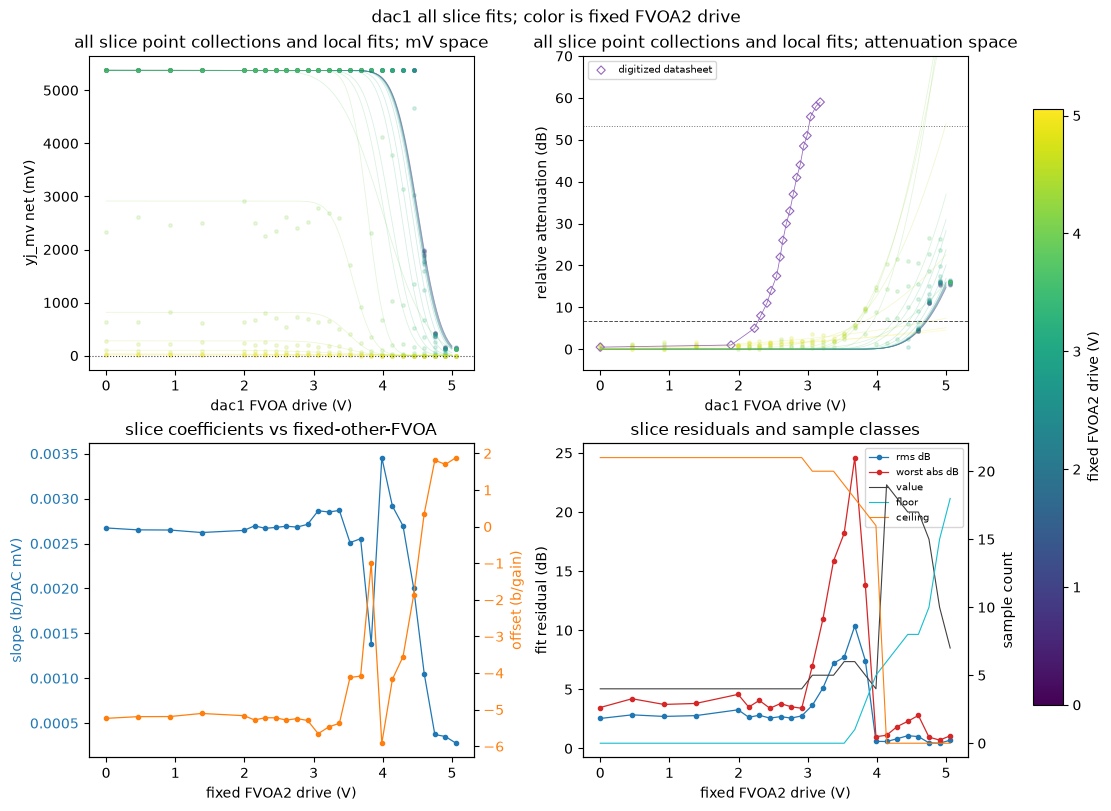

In [21]:
x.plot_slice('dac1', 'all')

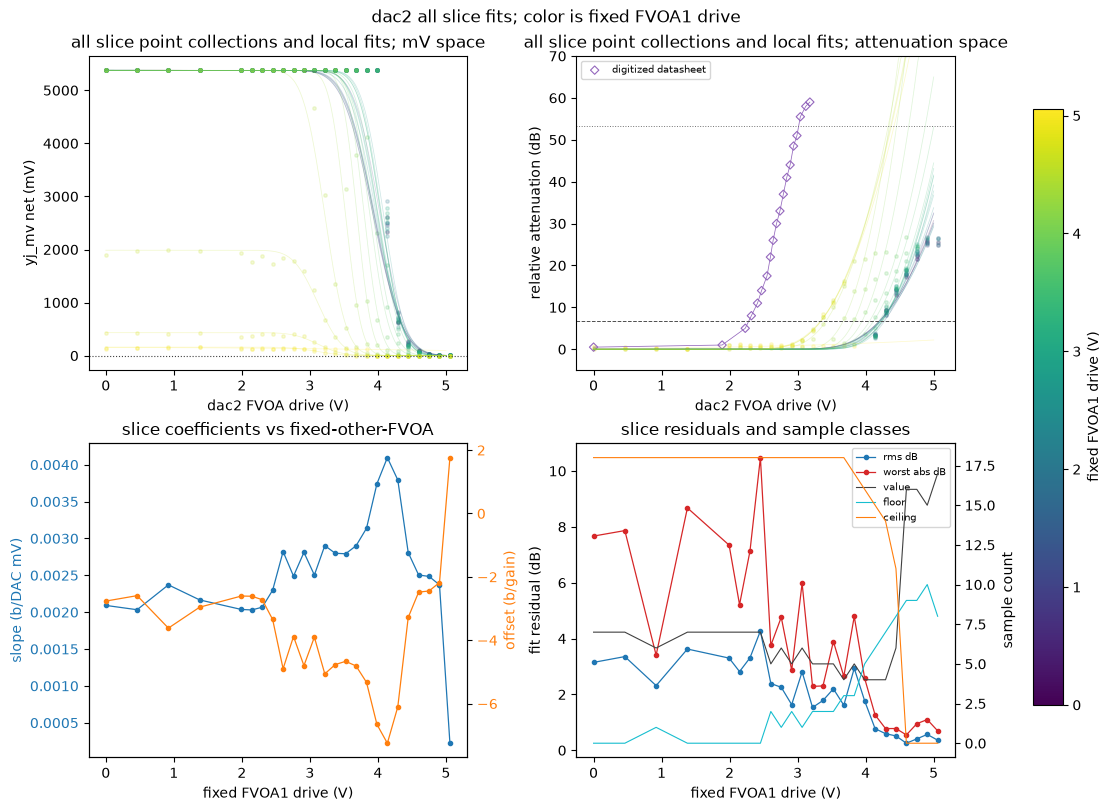

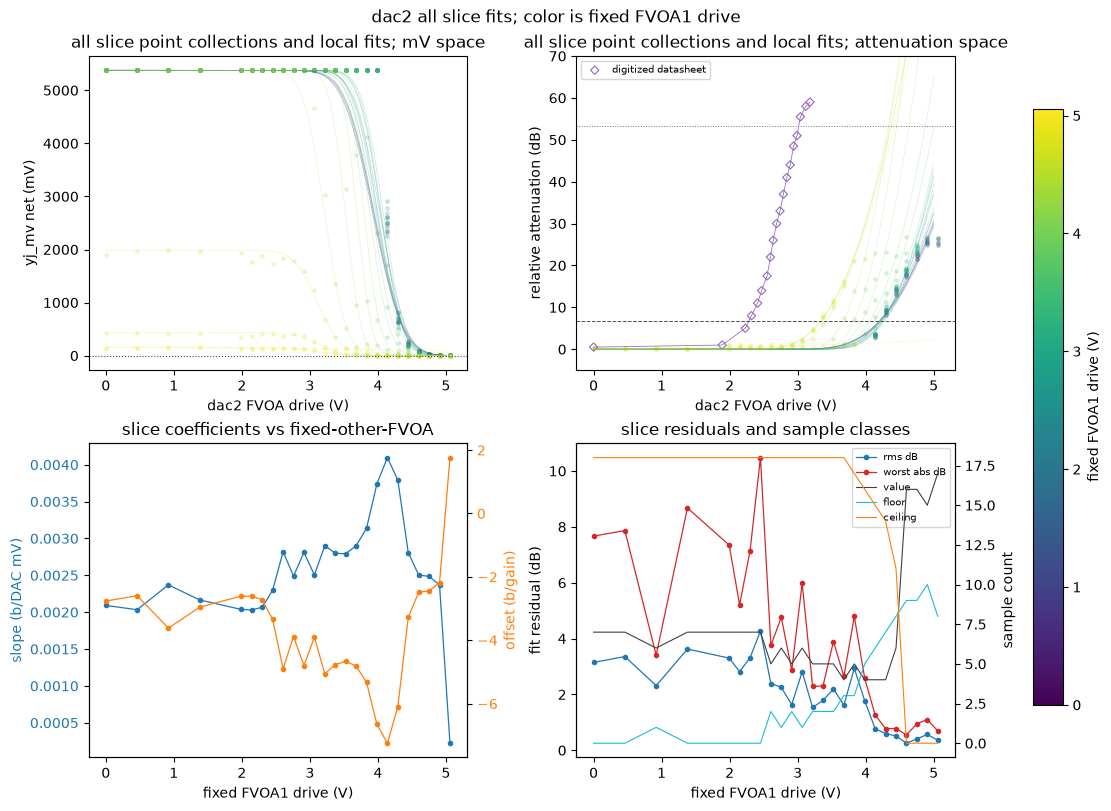

In [22]:
x.plot_slice('dac2', 'all')

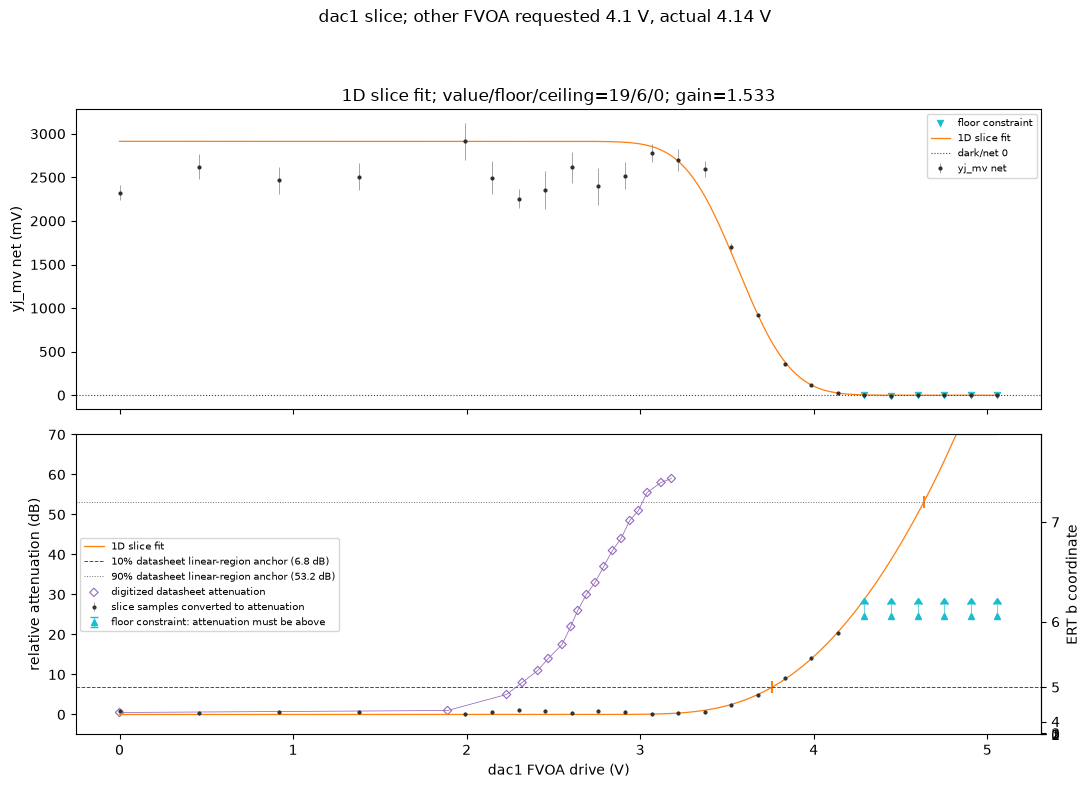

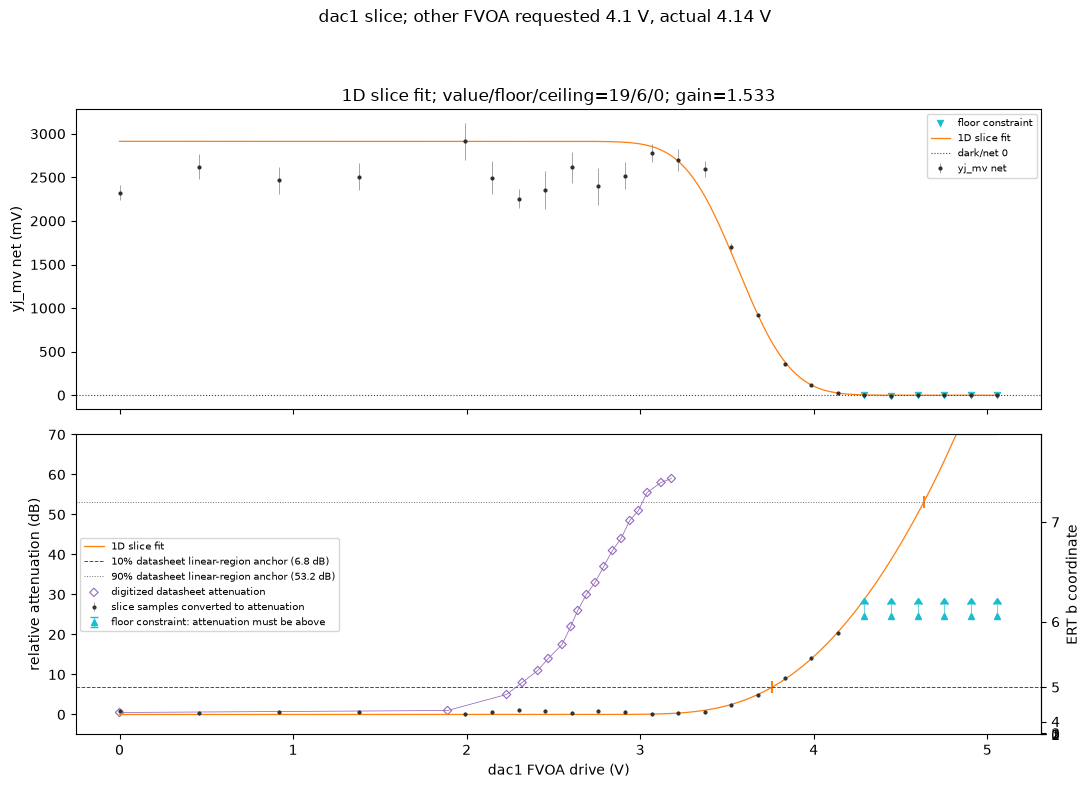

In [28]:
x.plot_slice('dac1', 4.1)

In [23]:
fit = x.fit(dac1_other_fvoa_v=4.1, dac2_other_fvoa_v=4.4)
fit

AttenuatorGridFit(
  channel='yj',
  points=625,
  estimated_unsaturated_unattenuated_pd_mv=3.06677e+07,
  dac1=(0.00291686, -4.16935),
  dac2=(0.00280782, -3.2812),
  dac1_other_fvoa_v=4.1391,
  dac2_other_fvoa_v=4.4457,
  dac1_sweep_plateau_pd_mv=2913.19,
  dac2_sweep_plateau_pd_mv=5376.19,
  gain1=1.533,
  gain2=1.533,
  rms_db=1560.55,
  worst_absdB_resid=3022.08,
  dac1_slices=1,
  dac2_slices=1,
  iterations=0,
  converged=True,
  accepted=True
)

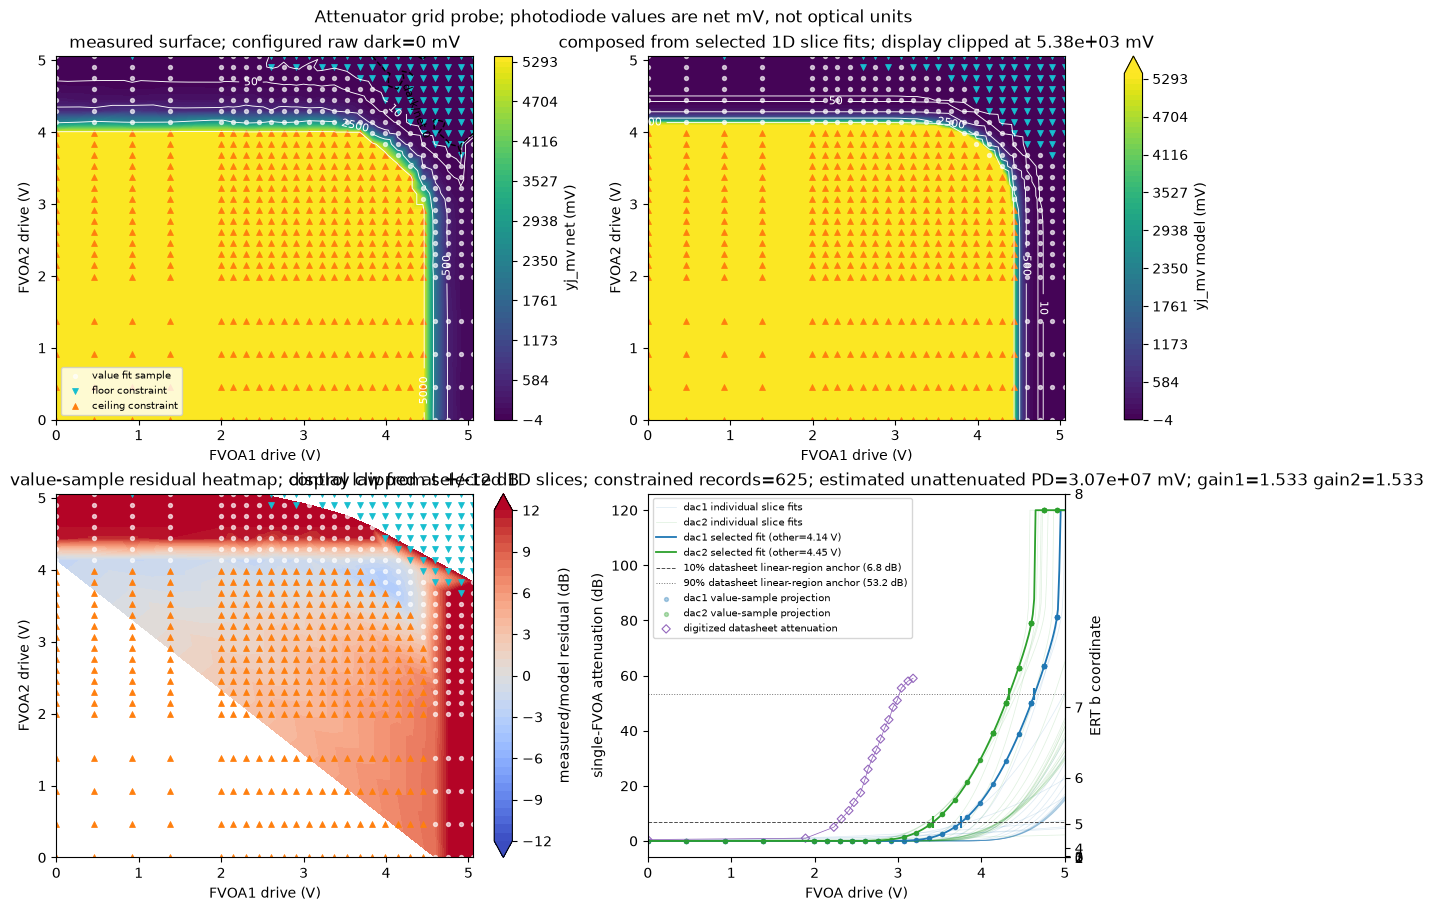

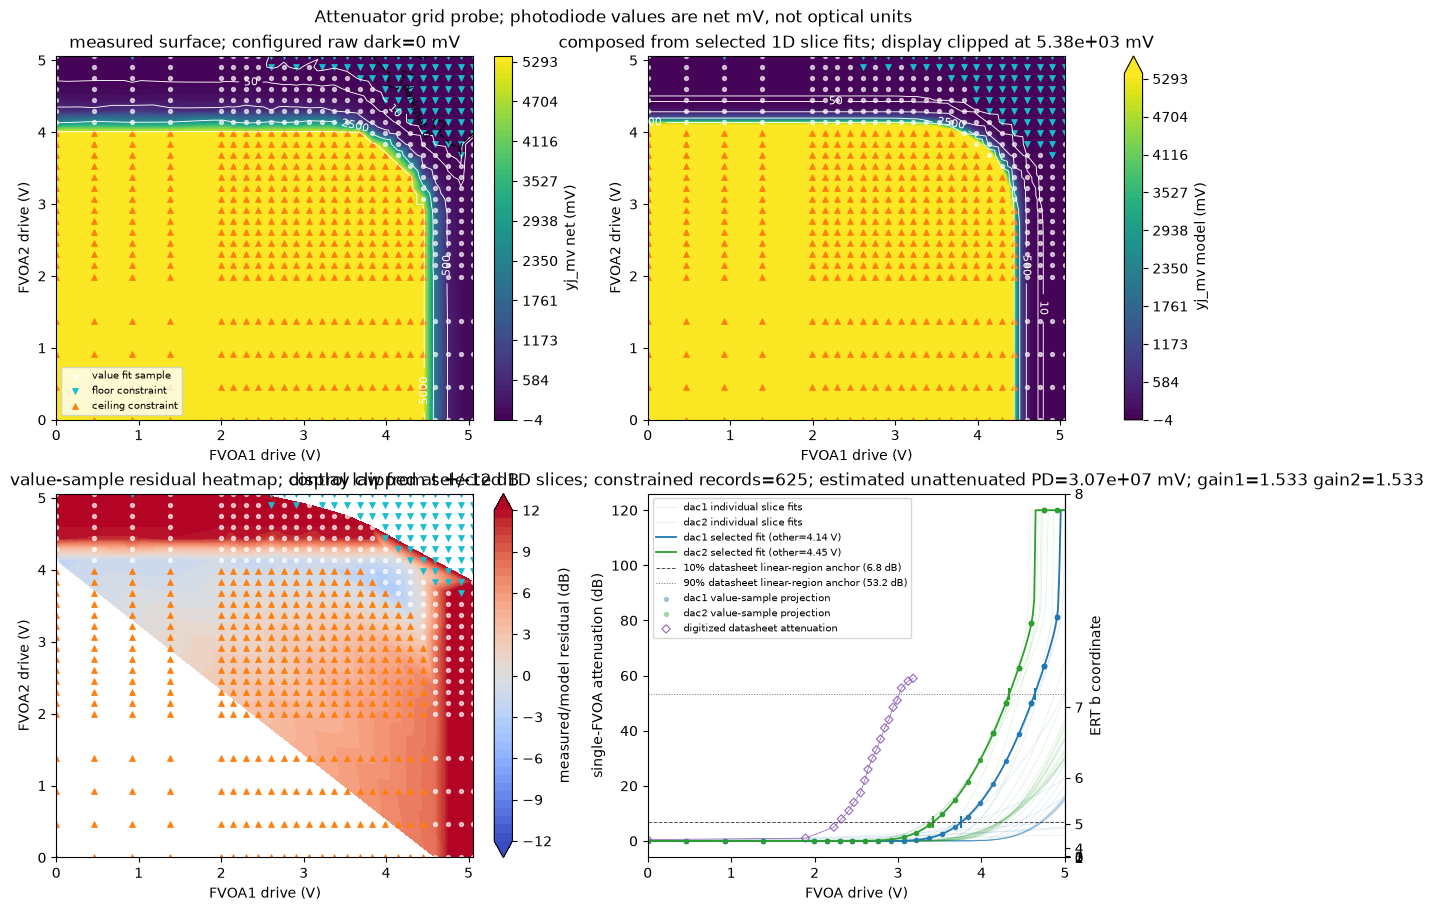

In [24]:
x.plot(fit=fit)

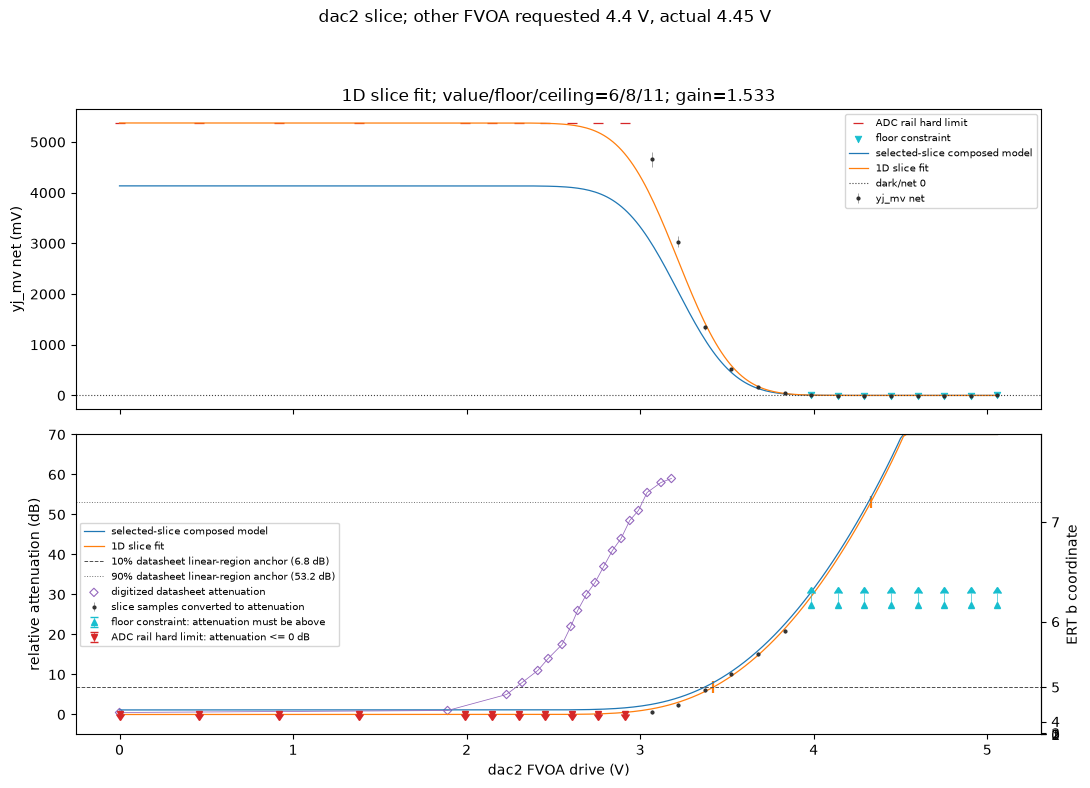

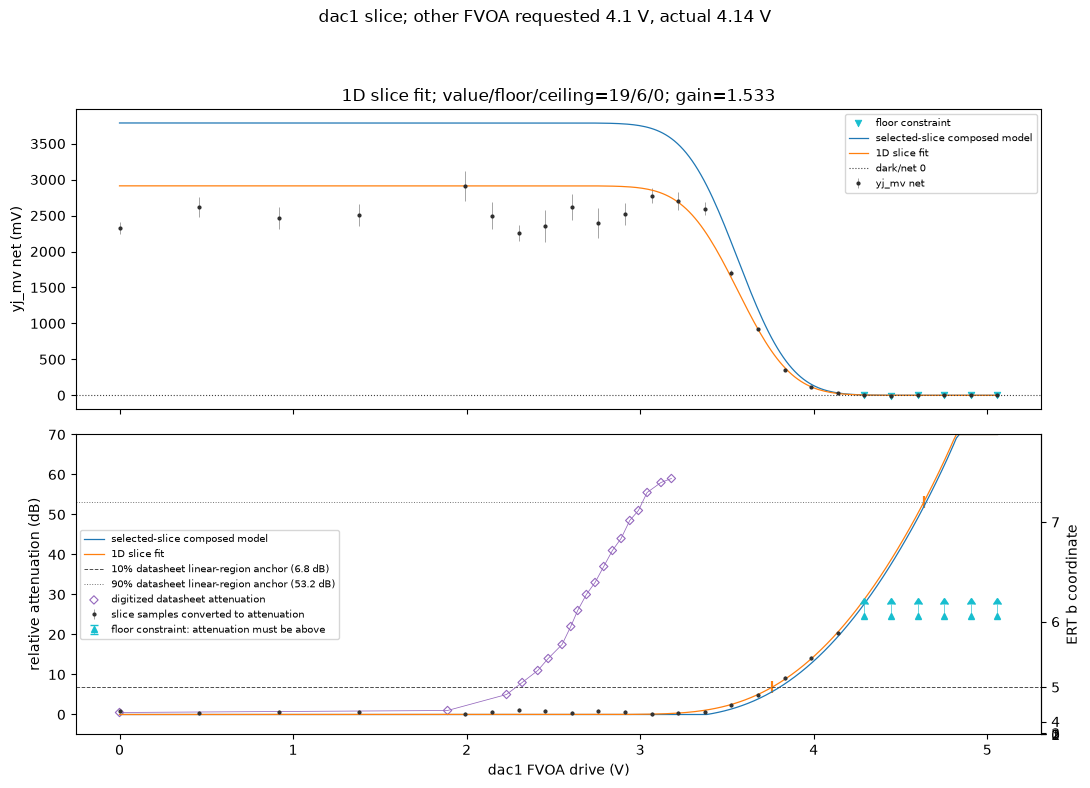

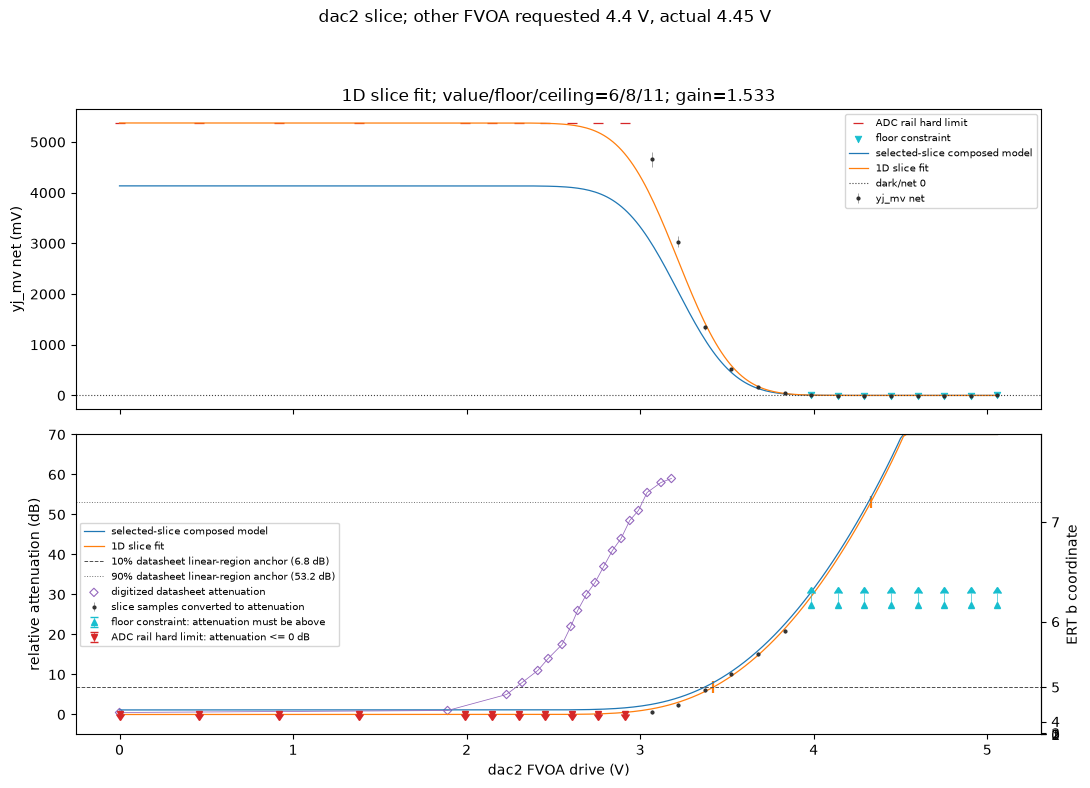

In [29]:
x.plot_slice('dac1', 4.1, fit=fit)
x.plot_slice('dac2', 4.4, fit=fit)

Raw data playground.

In [ ]:
rec = x.to_recarray()
rec.dtype, rec[:5]